# Sales Performance Analysis

### Project Overview

This project analyzes a retail sales dataset to identify sales trends, profit distribution, customer behavior, and regional performance using Python, Pandas, Matplotlib, and SQL.

---

### Objectives

- Perform data cleaning and preprocessing
- Analyze sales and profit trends
- Identify top-performing categories and regions
- Understand customer purchasing behavior
- Generate business insights for decision making

## Import Required Libraries

In [107]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Load Dataset

In [108]:
df=pd.read_csv("data/superstore.csv")
df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,1/1/2011,5/1/2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,1/1/2011,5/1/2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011


## Dataset Overview

In [109]:
df.shape

(51290, 21)

In [110]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  str    
 1   order_date      51290 non-null  str    
 2   ship_date       51290 non-null  str    
 3   ship_mode       51290 non-null  str    
 4   customer_name   51290 non-null  str    
 5   segment         51290 non-null  str    
 6   state           51290 non-null  str    
 7   country         51290 non-null  str    
 8   market          51290 non-null  str    
 9   region          51290 non-null  str    
 10  product_id      51290 non-null  str    
 11  category        51290 non-null  str    
 12  sub_category    51290 non-null  str    
 13  product_name    51290 non-null  str    
 14  sales           51290 non-null  str    
 15  quantity        51290 non-null  int64  
 16  discount        51290 non-null  float64
 17  profit          51290 non-null  float64
 1

In [111]:
df.describe()

,quantity,discount,profit,shipping_cost,year
count,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,3.476545,0.142908,28.641740,26.375915,2012.777208
std,2.278766,0.212280,174.424113,57.296804,1.098931
min,1.000000,0.000000,-6599.978000,0.000000,2011.000000
25%,2.000000,0.000000,0.000000,2.610000,2012.000000
50%,3.000000,0.000000,9.240000,7.790000,2013.000000
75%,5.000000,0.200000,36.810000,24.450000,2014.000000
max,14.000000,0.850000,8399.976000,933.570000,2014.000000


## Data Cleaning

### Standardize Column Names

In [112]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

df.columns

Index(['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name',
       'segment', 'state', 'country', 'market', 'region', 'product_id',
       'category', 'sub_category', 'product_name', 'sales', 'quantity',
       'discount', 'profit', 'shipping_cost', 'order_priority', 'year'],
      dtype='str')

### Check Missing Values

In [113]:
df.duplicated().sum()

np.int64(0)

### Verify Data Types

In [114]:
df.dtypes

order_id              str
order_date            str
ship_date             str
ship_mode             str
customer_name         str
segment               str
state                 str
country               str
market                str
region                str
product_id            str
category              str
sub_category          str
product_name          str
sales                 str
quantity            int64
discount          float64
profit            float64
shipping_cost     float64
order_priority        str
year                int64
dtype: object

### Convert Order Date to Datetime

In [115]:
df["order_date"] = pd.to_datetime(
    df["order_date"],
    format="mixed",
    dayfirst=True
)

df["order_date"].head()

0   2011-01-01
1   2011-01-01
2   2011-01-01
3   2011-01-01
4   2011-01-01
Name: order_date, dtype: datetime64[us]

### Create Date Features

In [116]:
df["year"] = df["order_date"].dt.year
df["month"] = df["order_date"].dt.month_name()
df["month_number"] = df["order_date"].dt.month
df["day"] = df["order_date"].dt.day_name()

df[["order_date", "year", "month", "day"]].head()

,order_date,year,month,day
0,2011-01-01,2011,January,Saturday
1,2011-01-01,2011,January,Saturday
2,2011-01-01,2011,January,Saturday
3,2011-01-01,2011,January,Saturday
4,2011-01-01,2011,January,Saturday


### Convert Sales Column to Numeric

In [117]:
df["sales"] = df["sales"].astype(str).str.replace(",", "")
df["sales"] = pd.to_numeric(df["sales"])

df["sales"].dtype

dtype('int64')

# Exploratory Data Analysis (EDA)

## 1. Total Sales by Category

### Business Question
Which product category generates the highest total sales?

In [118]:
category_sales = (
    df.groupby("category")["sales"]
    .sum()
    .sort_values(ascending=False)
)

category_sales

category
Technology         4744691
Furniture          4110884
Office Supplies    3787330
Name: sales, dtype: int64

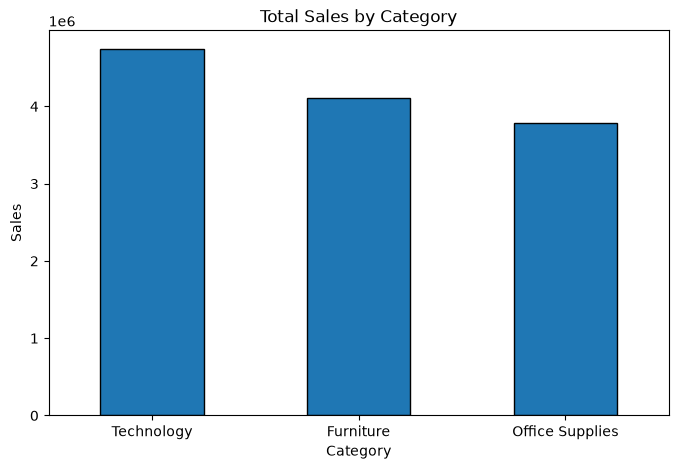

In [155]:
category_sales.plot(kind="bar", figsize=(8,5), edgecolor="black")

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.xticks(rotation=0)

plt.savefig("images/category_sales.png", dpi=300, bbox_inches="tight")

plt.show()

### Insight

- The highest total sales were generated by the Technology category.
- The lowest total sales were generated by the Office Supplies category.
- This indicates that customers purchased products from the Technology category more frequently than other categories.

## 2. Total Profit by Category

### Business Question
Which product category generates the highest total profit?

In [120]:
category_profit = (
    df.groupby("category")["profit"]
    .sum()
    .sort_values(ascending=False)
)

category_profit

category
Technology         663778.73318
Office Supplies    518473.83430
Furniture          286782.25380
Name: profit, dtype: float64

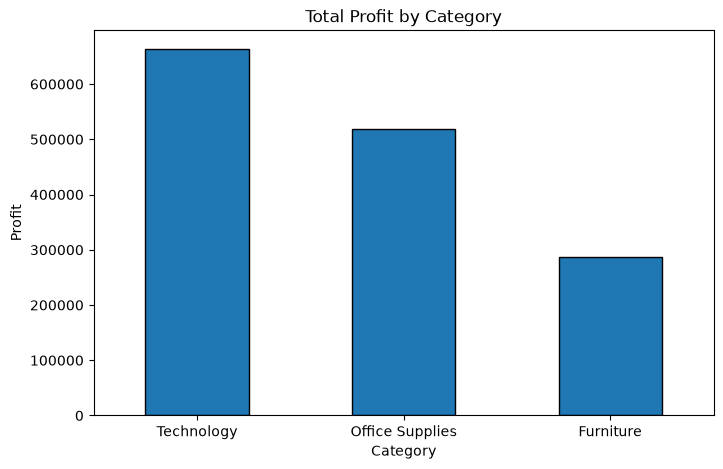

In [156]:
category_profit.plot(kind="bar", figsize=(8,5), edgecolor="black")

plt.title("Total Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")

plt.xticks(rotation=0)

plt.savefig("images/category_profit.png", dpi=300, bbox_inches="tight")

plt.show()

### Insight

- The Technology category generated the highest total profit.
- The Furniture category generated the lowest total profit.
- This suggests that the Technology category contributes the most to overall business profitability.

## 3. Top 10 States by Sales

### Business Question
Which states contribute the highest sales?

In [122]:
top_states_sales = (
    df.groupby("state")["sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_states_sales

state
England                   485166
California                457731
Ile-de-France             317818
New York                  310914
New South Wales           270509
Queensland                238311
North Rhine-Westphalia    216458
Texas                     170187
San Salvador              153648
National Capital          152185
Name: sales, dtype: int64

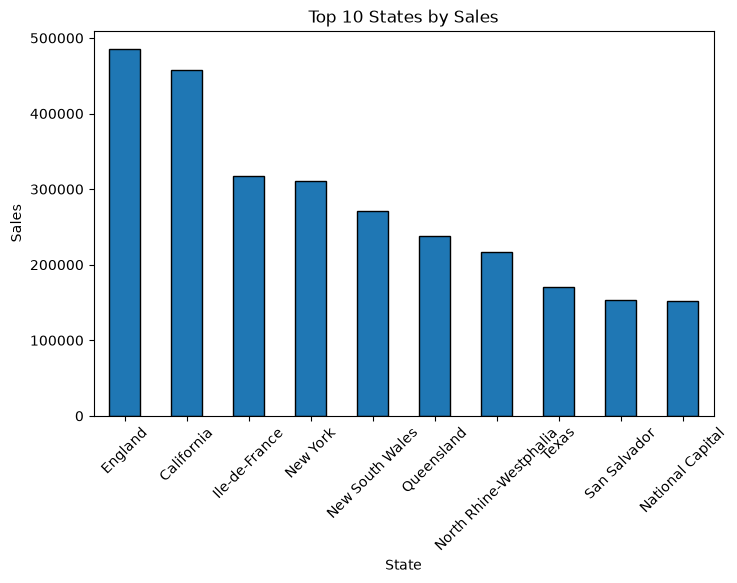

In [157]:
top_states_sales.plot(kind="bar", figsize=(8,5), edgecolor="black")

plt.title("Top 10 States by Sales")
plt.xlabel("State")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.savefig("images/state_sales.png", dpi=300, bbox_inches="tight")

plt.show()

### Insight

- England recorded the highest total sales.
- National Capital had the lowest sales among the top 10 states.
- Sales are concentrated in a few high-performing states.

## 4. Top 10 States by Profit

### Business Question
Which states generate the highest profit?

In [124]:
top_states_profit = (
    df.groupby("state")["profit"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_states_profit

state
England                   99907.73100
California                76381.38710
New York                  74038.54860
New South Wales           45273.51400
Ile-de-France             44055.92400
North Rhine-Westphalia    42347.87100
San Salvador              35883.37700
Washington                33402.65170
Michigan                  24463.18760
São Paulo                 21878.02388
Name: profit, dtype: float64

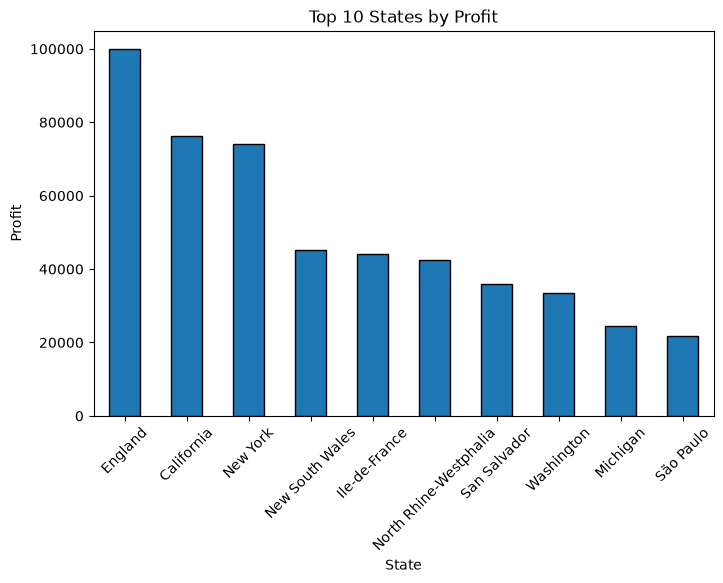

In [158]:
top_states_profit.plot(kind="bar", figsize=(8,5), edgecolor="black")

plt.title("Top 10 States by Profit")
plt.xlabel("State")
plt.ylabel("Profit")

plt.xticks(rotation=45)

plt.savefig("images/state_profit.png", dpi=300, bbox_inches="tight")

plt.show()

### Insight

- England generated the highest profit.
- Sao Paulo generated the lowest profit among the top-performing states.
- These states contribute significantly to the company's overall profitability.

## 5. Total Sales by Customer Segment

### Business Question
Which customer segment contributes the highest sales?

In [126]:
segment_sales = (
    df.groupby("segment")["sales"]
    .sum()
    .sort_values(ascending=False)
)

segment_sales

segment
Consumer       6508141
Corporate      3824808
Home Office    2309956
Name: sales, dtype: int64

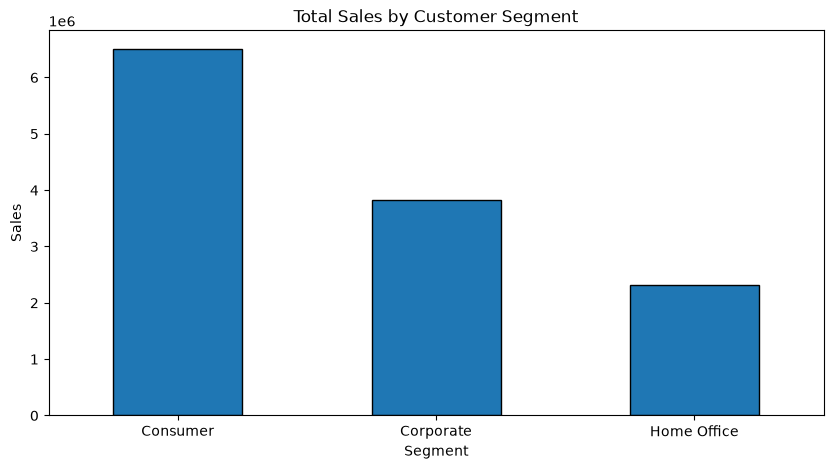

In [159]:
segment_sales.plot(kind="bar", figsize=(10,5), edgecolor="black")

plt.title("Total Sales by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Sales")

plt.xticks(rotation=0)

plt.savefig("images/segment_sales.png", dpi=300, bbox_inches="tight")

plt.show()

### Insight

- The Consumer segment generated the highest sales.
- The Home Office segment contributed the lowest sales.
- The business relies heavily on the Consumer customer segment.

## 6. Total Profit by Customer Segment

### Business Question
Which customer segment generates the highest profit?

In [128]:
segment_profit = (
    df.groupby("segment")["profit"]
    .sum()
    .sort_values(ascending=False)
)

segment_profit

segment
Consumer       749239.78206
Corporate      442785.85866
Home Office    277009.18056
Name: profit, dtype: float64

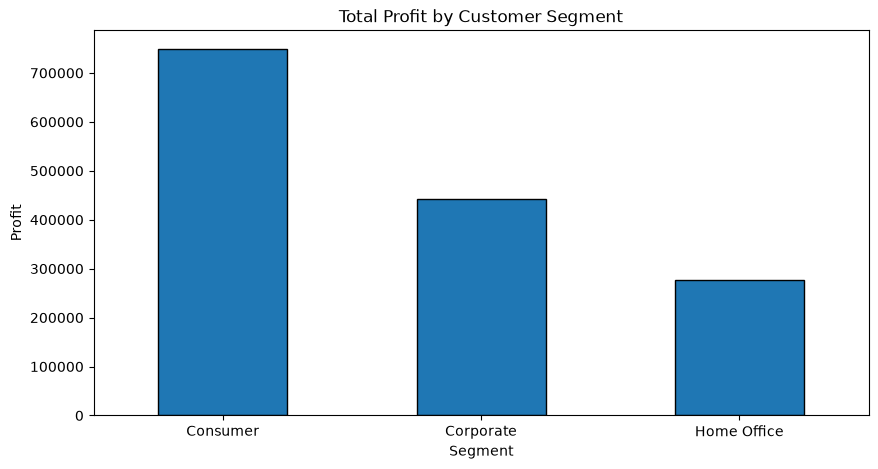

In [160]:
segment_profit.plot(kind="bar", figsize=(10,5), edgecolor="black")

plt.title("Total Profit by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Profit")

plt.xticks(rotation=0)

plt.savefig("images/segment_profit.png", dpi=300, bbox_inches="tight")

plt.show()

### Insight

- The Consumer segment generated the highest profit.
- The Home Office segment generated the lowest profit.
- Increasing engagement with the Consumer segment could improve profitability.

## 7. Sales by Sub-Category

### Business Question
Which product sub-categories generate the highest sales?

In [130]:
subcategory_sales = (
    df.groupby("sub_category")["sales"]
    .sum()
    .sort_values(ascending=False)
)

subcategory_sales

sub_category
Phones         1706874
Copiers        1509439
Chairs         1501682
Bookcases      1466559
Storage        1127124
Appliances     1011081
Machines        779071
Tables          757034
Accessories     749307
Binders         461952
Furnishings     385609
Art             372163
Paper           244307
Supplies        243090
Envelopes       170926
Fasteners        83254
Labels           73433
Name: sales, dtype: int64

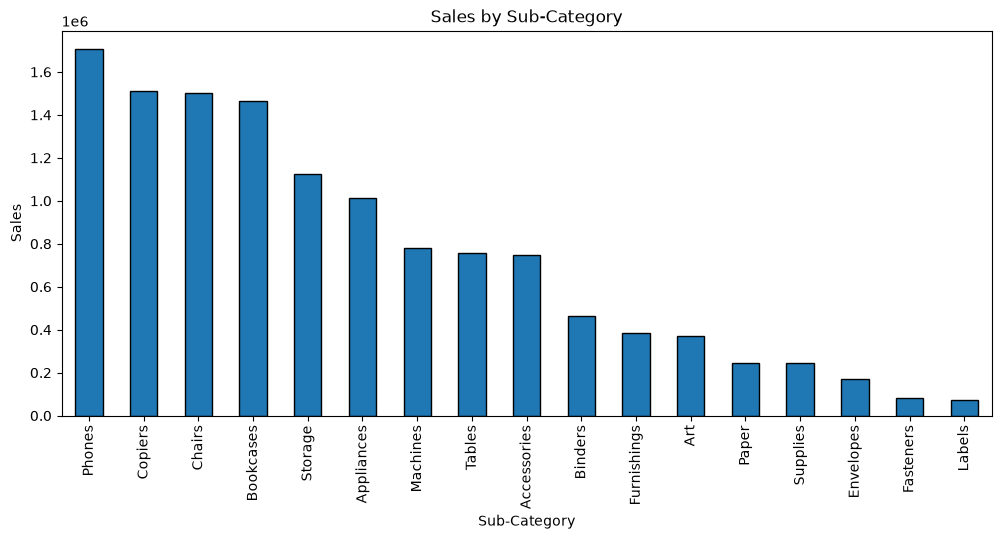

In [161]:
subcategory_sales.plot(kind="bar", figsize=(12,5), edgecolor="black")

plt.title("Sales by Sub-Category")
plt.xlabel("Sub-Category")
plt.ylabel("Sales")

plt.xticks(rotation=90)

plt.savefig("images/subcategory_sales.png", dpi=300, bbox_inches="tight")

plt.show()

### Insight

- Phones recorded the highest sales among all sub-categories.
- Labels recorded the lowest sales.
- Customer demand is highest for Phones.

## 8. Profit by Sub-Category

### Business Question
Which product sub-categories generate the highest profit?

In [132]:
subcategory_profit = (
    df.groupby("sub_category")["profit"]
    .sum()
    .sort_values(ascending=False)
)

subcategory_profit

sub_category
Copiers        258567.54818
Phones         216717.00580
Bookcases      161924.41950
Chairs         141973.79750
Appliances     141680.58940
Accessories    129626.30620
Storage        108461.48980
Binders         72449.84600
Paper           59207.68270
Machines        58867.87300
Art             57953.91090
Furnishings     46967.42550
Envelopes       29601.11630
Supplies        22583.26310
Labels          15010.51200
Fasteners       11525.42410
Tables         -64083.38870
Name: profit, dtype: float64

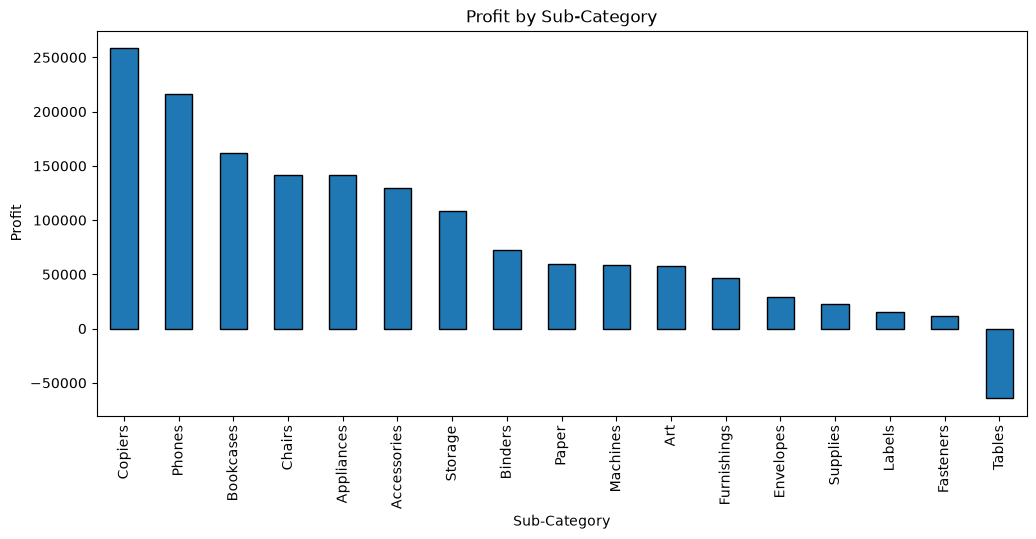

In [162]:
subcategory_profit.plot(kind="bar", figsize=(12,5), edgecolor="black")

plt.title("Profit by Sub-Category")
plt.xlabel("Sub-Category")
plt.ylabel("Profit")

plt.xticks(rotation=90)

plt.savefig("images/subcategory_profit.png", dpi=300, bbox_inches="tight")

plt.show()

### Insight

- Coolers generated the highest profit.
- Tables generated the lowest profit.
- Profitability differs significantly across product sub-categories.

## 9. Total Sales by Region

### Business Question

Which region generates the highest total sales?

In [134]:
region_sales = (
    df.groupby("region")["sales"]
    .sum()
    .sort_values(ascending=False)
)

print(region_sales)

region
Central           2822399
South             1600960
North             1248192
Oceania           1100207
Southeast Asia     884438
North Asia         848349
EMEA               806184
Africa             783776
Central Asia       752839
West               725514
East               678834
Caribbean          324281
Canada              66932
Name: sales, dtype: int64


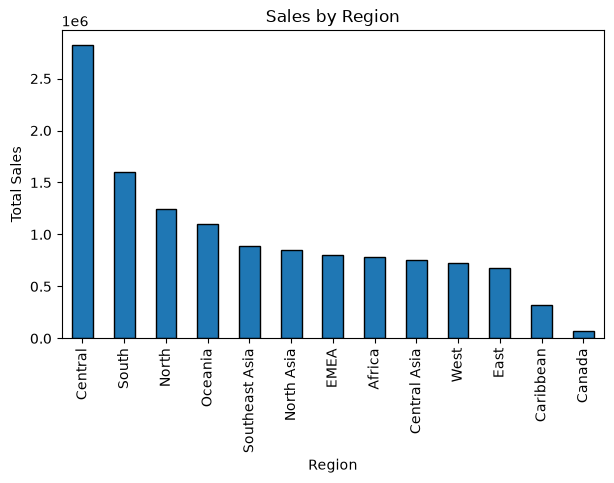

In [163]:
region_sales.plot(
    kind="bar",
    figsize=(7,4), edgecolor="black"
)

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.savefig("images/region_sales.png", dpi=300, bbox_inches="tight")

plt.show()

### Insight

- The Central region generated the highest sales.
- The Canada region generated the lowest sales.
- This suggests stronger customer demand in the Central region.

## 10. Total Profit by Region

### Business Question

Which region generates the highest total profit?

In [136]:
region_profit = (
    df.groupby("region")["profit"]
    .sum()
    .sort_values(ascending=False)
)

print(region_profit)

region
Central           311403.98164
North             194597.95252
North Asia        165578.42100
South             140355.76618
Central Asia      132480.18700
Oceania           121666.64200
West              108418.44890
East               91522.78000
Africa             88871.63100
EMEA               43897.97100
Caribbean          34571.32104
Southeast Asia     17852.32900
Canada             17817.39000
Name: profit, dtype: float64


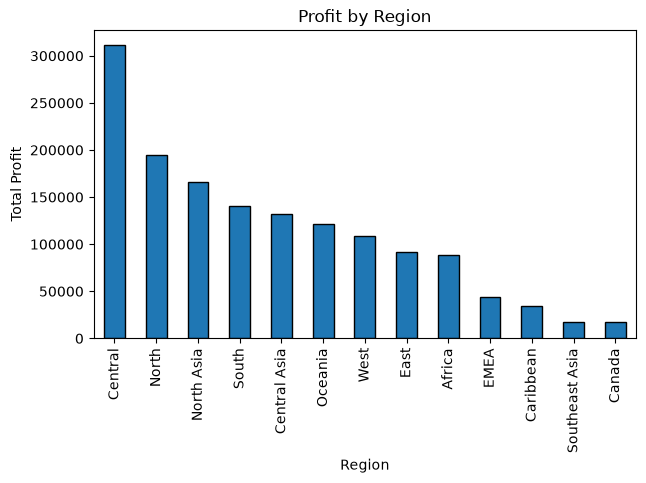

In [164]:
region_profit.plot(
    kind="bar",
    figsize=(7,4), edgecolor="black"
)

plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Total Profit")

plt.savefig("images/region_profit.png", dpi=300, bbox_inches="tight")

plt.show()

### Insight

- The Central region generated the highest profit.
- The Canada region generated the lowest profit.
- The Central region contributes the most to overall business profitability.

## 11. Total Profit by Region

### Business Question

Which shipping mode contributes the highest total sales?

In [138]:
ship_sales = (
    df.groupby("ship_mode")["sales"]
    .sum()
    .sort_values(ascending=False)
)

print(ship_sales)

ship_mode
Standard Class    7578889
Second Class      2565747
First Class       1831067
Same Day           667202
Name: sales, dtype: int64


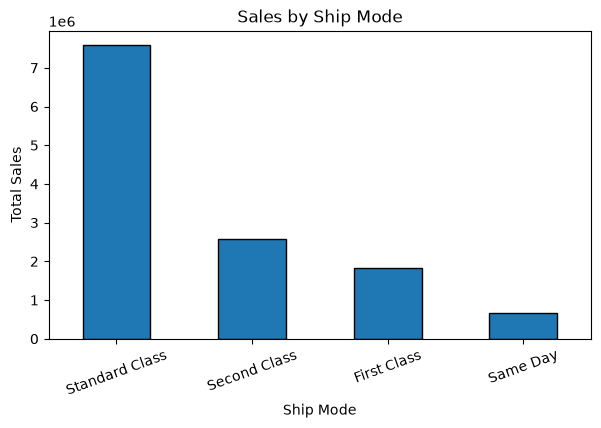

In [165]:
ship_sales.plot(
    kind="bar",
    figsize=(7,4), edgecolor="black"
)

plt.title("Sales by Ship Mode")
plt.xlabel("Ship Mode")
plt.ylabel("Total Sales")
plt.xticks(rotation=20)

plt.savefig("images/ship_sales.png", dpi=300, bbox_inches="tight")

plt.show()

### Insight

- The Standard Class shipping mode generated the highest sales.
- The Same Day shipping mode generated the lowest sales.
- Customers appear to prefer the Standard Class shipping option.

## 12. Monthly Sales Trend

### Business Question

How do total sales vary across different months?

In [140]:
monthly_sales = (
    df.groupby(["month_number", "month"])["sales"]
    .sum()
    .reset_index()
    .sort_values("month_number")
)

print(monthly_sales)

    month_number      month    sales
0              1    January   675141
1              2   February   543768
2              3      March   770519
3              4      April   698603
4              5        May   904061
5              6       June  1269751
6              7       July   749423
7              8     August  1293852
8              9  September  1437432
9             10    October  1168220
10            11   November  1551319
11            12   December  1580816


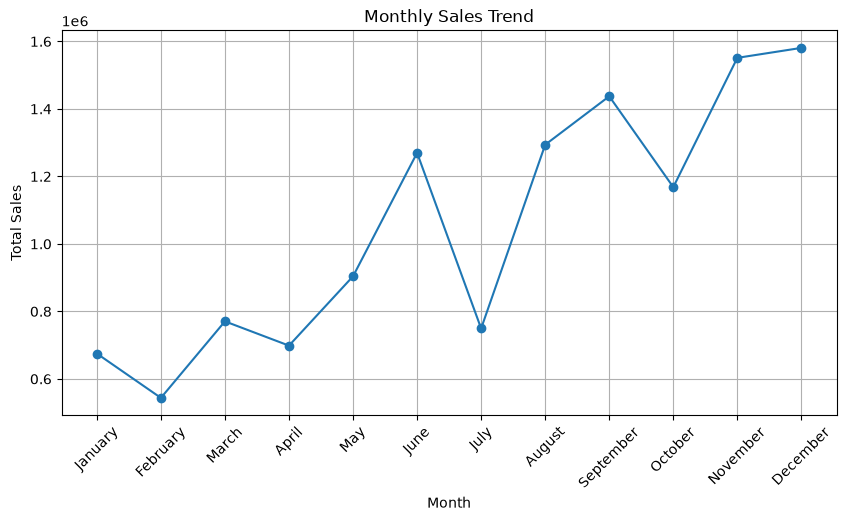

In [166]:
plt.figure(figsize=(10,5))

plt.plot(
    monthly_sales["month"],
    monthly_sales["sales"],
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.savefig("images/monthly_sales.png", dpi=300, bbox_inches="tight")

plt.grid(True)

plt.show()

### Insight

- Sales reached their peak in December.
- Sales were lowest in February.
- Monthly sales fluctuate throughout the year, indicating seasonal demand patterns.

## 13. Monthly Profit Trend

### Business Question

How does total profit change across different months?

In [142]:
monthly_profit = (
    df.groupby(["month_number", "month"])["profit"]
    .sum()
    .reset_index()
    .sort_values("month_number")
)

print(monthly_profit)

    month_number      month        profit
0              1    January   73535.38454
1              2   February   72509.72922
2              3      March   94087.52096
3              4      April   73513.63124
4              5        May  104509.78428
5              6       June  147079.41684
6              7       July   78070.09172
7              8     August  151854.10972
8              9  September  170438.18316
9             10    October  157269.35838
10            11   November  175449.48412
11            12   December  170718.12710


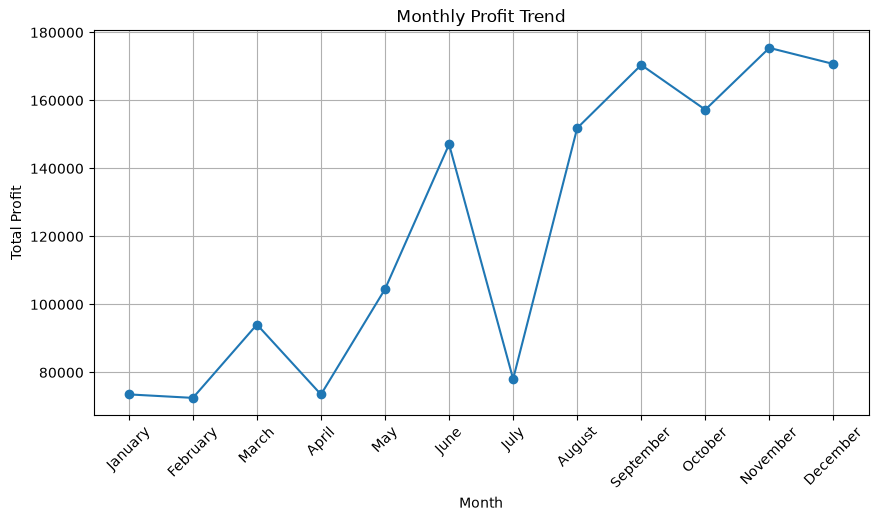

In [167]:
plt.figure(figsize=(10,5))

plt.plot(
    monthly_profit["month"],
    monthly_profit["profit"],
    marker="o"
)

plt.title("Monthly Profit Trend")
plt.xlabel("Month")
plt.ylabel("Total Profit")

plt.xticks(rotation=45)

plt.savefig("images/monthly_profit.png", dpi=300, bbox_inches="tight")

plt.grid(True)

plt.show()

### Insight

- Profit was highest in November.
- Profit was lowest in February.
- Profitability varies across different months due to changes in sales and discounts.

## 14. Yearly Sales Trend

### Business Question

How have total sales changed over the years?

In [144]:
yearly_sales = (
    df.groupby("year")["sales"]
    .sum()
)

yearly_sales

year
2011    2259511
2012    2677493
2013    3405860
2014    4300041
Name: sales, dtype: int64

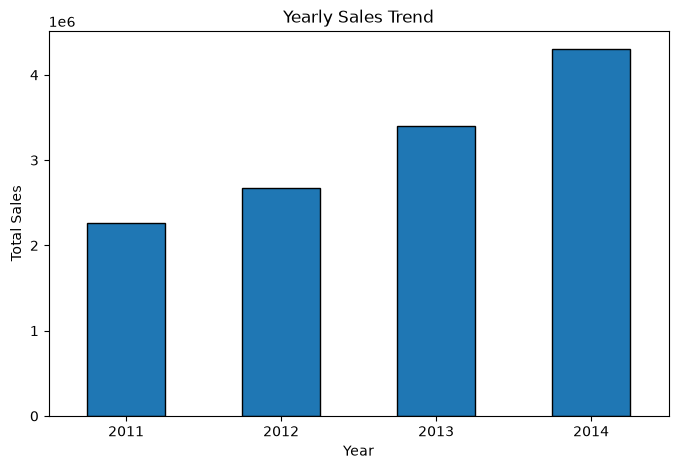

In [168]:
yearly_sales.plot(kind="bar", figsize=(8,5), edgecolor="black")

plt.title("Yearly Sales Trend")
plt.xlabel("Year")
plt.ylabel("Total Sales")

plt.xticks(rotation=0)

plt.savefig("images/yearly_sales.png", dpi=300, bbox_inches="tight")

plt.show()

### Insight

- The highest sales were recorded in 2014.
- The lowest sales were recorded in 2011.
- Sales show an increasing trend over the years.

## 15. Yearly Profit Trend

### Business Question

How has total profit changed over the years?

In [146]:
yearly_profit = (
    df.groupby("year")["profit"]
    .sum()
)

yearly_profit

year
2011    248940.81154
2012    307415.27910
2013    408512.76018
2014    504165.97046
Name: profit, dtype: float64

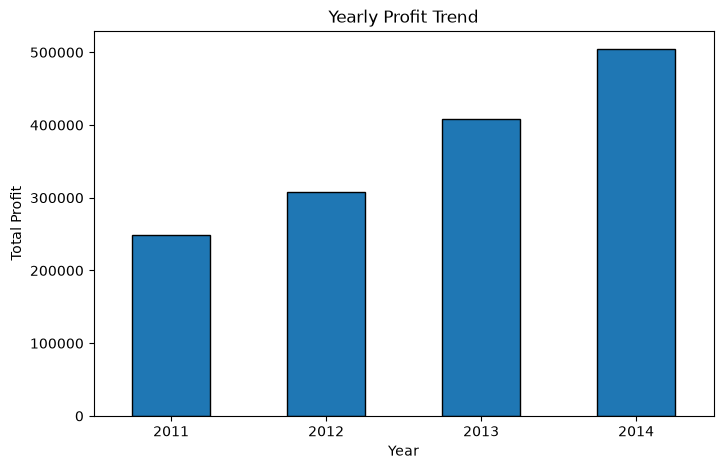

In [169]:
yearly_profit.plot(kind="bar", figsize=(8,5), edgecolor="black")

plt.title("Yearly Profit Trend")
plt.xlabel("Year")
plt.ylabel("Total Profit")

plt.xticks(rotation=0)

plt.savefig("images/yearly_profit.png", dpi=300, bbox_inches="tight")

plt.show()

### Insight

- The highest profit was recorded in 2014.
- The lowest profit was recorded in 2011.
- Overall profitability has shown an increasing trend over time.

## 16. Yearly Profit Trend

### Business Question

How has total profit changed over the years?

In [148]:
top_customers_sales = (
    df.groupby("customer_name")["sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_customers_sales)

customer_name
Tom Ashbrook          40489
Tamara Chand          37453
Greg Tran             35552
Christopher Conant    35187
Sean Miller           35170
Bart Watters          32315
Natalie Fritzler      31778
Fred Hopkins          30404
Jane Waco             30288
Hunter Lopez          30246
Name: sales, dtype: int64


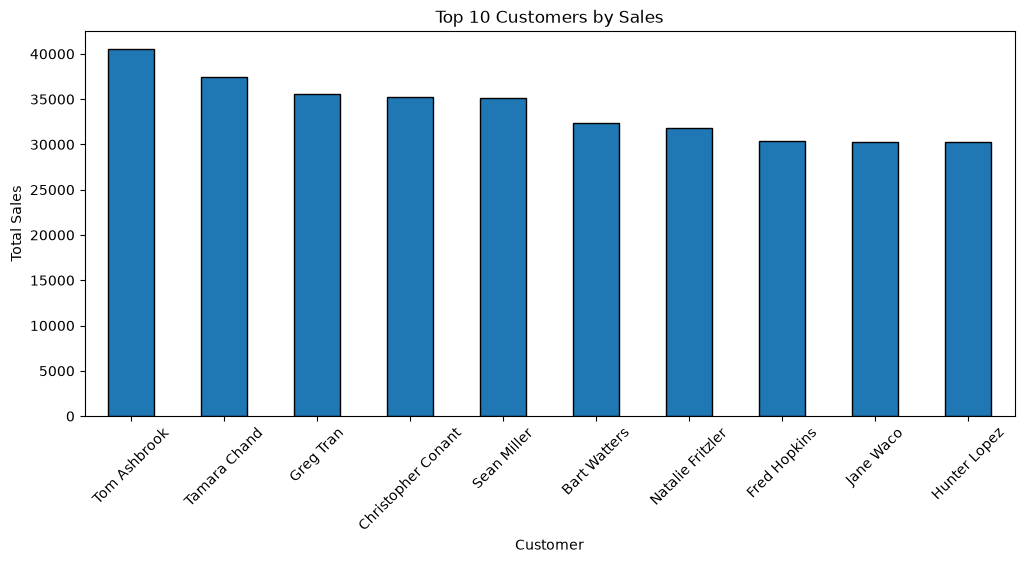

In [170]:
top_customers_sales.plot(
    kind="bar",
    figsize=(12,5), edgecolor="black"
)

plt.title("Top 10 Customers by Sales")
plt.xlabel("Customer")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.savefig("images/top_customers_sales.png", dpi=300, bbox_inches="tight")

plt.show()

### Insight

- Tom Ashbrook is the highest revenue-generating customer.
- The top 10 customers contribute a significant portion of total sales.
- Retaining these customers is important for business growth.

## 17. Top 10 Products by Sales

### Business Question

Which products generate the highest total sales?

In [150]:
top_products_sales = (
    df.groupby("product_name")["sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products_sales)

product_name
Apple Smart Phone, Full Size                                86936
Cisco Smart Phone, Full Size                                76441
Motorola Smart Phone, Full Size                             73159
Nokia Smart Phone, Full Size                                71904
Canon imageCLASS 2200 Advanced Copier                       61600
Hon Executive Leather Armchair, Adjustable                  58200
Office Star Executive Leather Armchair, Adjustable          50667
Harbour Creations Executive Leather Armchair, Adjustable    50120
Samsung Smart Phone, Cordless                               48654
Nokia Smart Phone, with Caller ID                           47880
Name: sales, dtype: int64


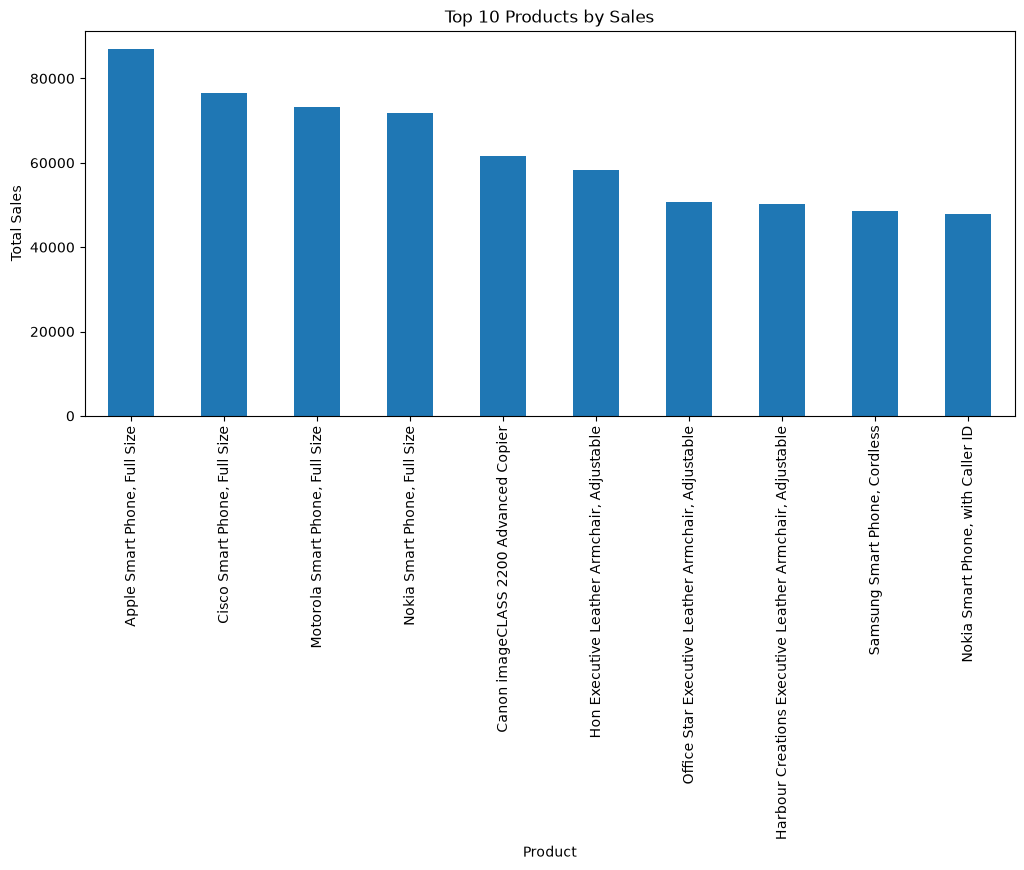

In [171]:
top_products_sales.plot(
    kind="bar",
    figsize=(12,5)
)

plt.title("Top 10 Products by Sales")
plt.xlabel("Product")
plt.ylabel("Total Sales")

plt.xticks(rotation=90)

plt.savefig("images/top_products_sales.png", dpi=300, bbox_inches="tight")

plt.show()

### Insight

- Apple Smart Phones.Full Size is the highest-selling product.
- The top-selling products contribute significantly to total revenue.
- These products represent the company's strongest-performing offerings.

## 18. Discount vs Profit

### Business Question

How does discount affect profit?

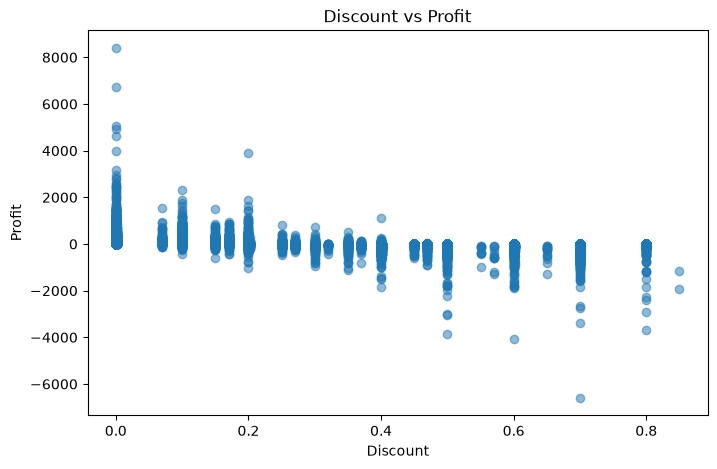

In [172]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["discount"],
    df["profit"],
    alpha=0.5
)

plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.savefig("images/discount_profit.png", dpi=300, bbox_inches="tight")

plt.show()

### Insight

- Higher discounts generally tend to reduce profitability.
- Some highly discounted orders resulted in low or negative profit.
- Discounts should be applied strategically to avoid unnecessary losses.

## 19. Correlation Matrix

### Business Question

Which numerical features are strongly correlated with each other?

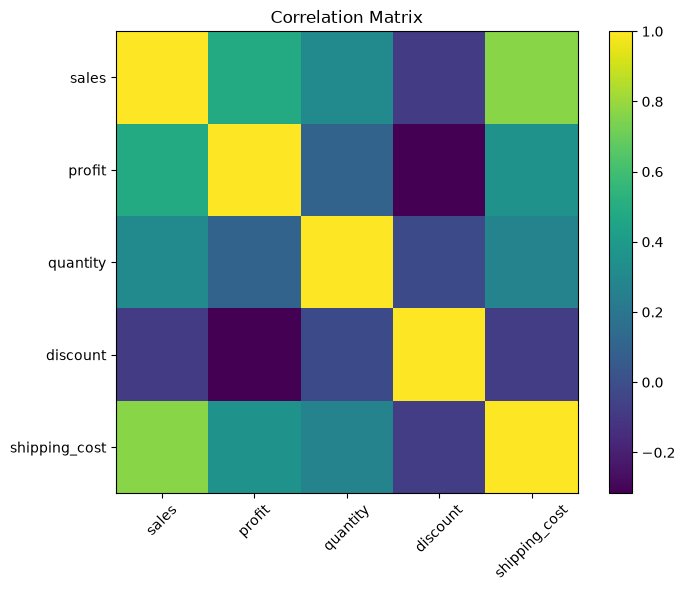

In [173]:
correlation = df[["sales", "profit", "quantity", "discount", "shipping_cost"]].corr()

plt.figure(figsize=(8,6))

plt.imshow(correlation, cmap="viridis")

plt.colorbar()

plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=45)
plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.title("Correlation Matrix")

plt.savefig("images/correlation_matrix.png", dpi=300, bbox_inches="tight")

plt.show()

### Insight

- Sales and profit show a **moderate positive** relationship.
- Discount has a **negative** relationship with profit.
- Correlation values help identify relationships between numerical variables and support data-driven decision making.

## 20. Sales Distribution

### Business Question

How are sales values distributed across all orders?

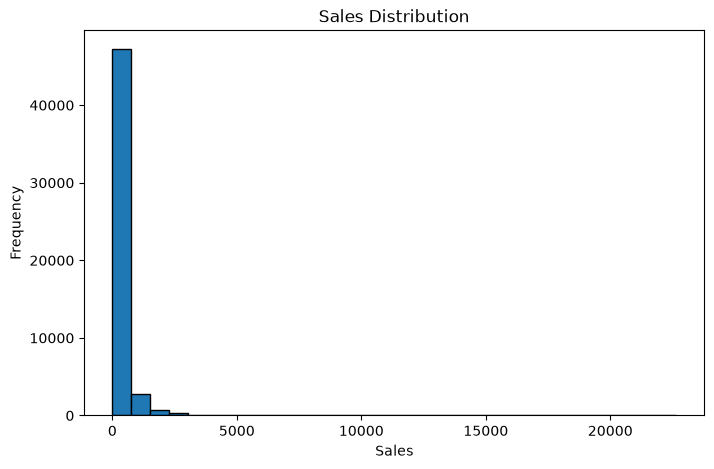

In [174]:
plt.figure(figsize=(8,5))

plt.hist(df["sales"], bins=30, edgecolor='black')

plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.savefig("images/sales_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

### Insight

- Most orders fall within the **0–1000** sales range.
- Only a small number of orders have very high sales values.
- The sales distribution is **right-skewed**.


#   Key Business Insights

### Business Question

What are the key business insights obtained from this analysis?

### Insight

- Highest Sales Category:
- Highest Profit Category:
- Best Performing Region:
- Best Performing State:
- Best Customer Segment:
- Highest Selling Sub-Category:
- Most Profitable Sub-Category:
- Best Ship Mode:
- Top Customer:
- Top Product:
- Monthly Sales Trend:
- Yearly Sales Trend:
- Discount vs Profit:

# Conclusion

### Business Question

What are the overall findings of this sales performance analysis?

### Insight

This project analyzed retail sales data using Python, Pandas, Matplotlib, and SQL. The analysis identified sales trends, profitable product categories, customer purchasing behavior, regional performance, and the impact of discounts on profitability. These findings can help businesses make informed, data-driven decisions.